# Introducción a Pandas

[Pandas](https://pandas.pydata.org/about/index.html) es una librería que proporciona estructuras de datos y herramientas de análisis de datos de alto rendimiento y fáciles de usar. 
* La estructura de datos principal es el DataFrame, que puede considerarse como una tabla 2D en memoria (como una hoja de cálculo, con nombres de columna y etiquetas de fila). 
* Muchas funciones disponibles en Excel están disponibles mediante programación, como crear tablas dinámicas, calcular columnas basadas en otras columnas, trazar gráficos, etc.
* Proporciona un alto rendimiento para manipular (unir, dividir, modificar…) grandes conjuntos de datos

## Instalación de pandas
Se puede instalar desde una terminal abierta desde el gestor de entornos de anaconda con la siguiente instrucción
* pip3 install pandas
o desde una celda del cuadernillo con:
* !pip3 install pandas

## Import

In [146]:
import pandas as pd

## Estructuras de datos en Pandas

La librería Pandas, de manera genérica, contiene las siguientes estructuras de datos:
* **Series**: Array de una dimensión
* **DataFrame**: Se corresponde con una tabla de 2 dimensiones
* **Panel**: Similar a un diccionario de DataFrames

## Creación del objeto Series

In [147]:
# Creacion de un objeto Series
serie = pd.Series( [ 2, 4, 6, 8, 10 ] )
print( serie )

0     2
1     4
2     6
3     8
4    10
dtype: int64


In [148]:
# Creación de un objeto Series inicializándolo con un diccionario de Python
altura = {"Santiago": 187, "Pedro": 178, "Julia": 170, "Ana": 165}
serie = pd.Series( altura )
print( serie )

Santiago    187
Pedro       178
Julia       170
Ana         165
dtype: int64


In [149]:
# Creación de un objeto Series inicializándolo con algunos 
# de los elementos de un diccionario de Python
altura = {"Santiago": 187, "Pedro": 178, "Julia": 170, "Ana": 165}
serie = pd.Series( altura, index = { "Pedro", "Julia" } )
print( serie )

Pedro    178
Julia    170
dtype: int64


In [150]:
# Creación de un objeto Series inicializandolo con un escalar
serie = pd.Series( 34, [ "test1", "test2", "test3" ])
print( serie )

test1    34
test2    34
test3    34
dtype: int64


## Acceso a los elementos de un objeto Series

Cada elemento en un objeto Series tiene un identificador único que se denomina **_index label_**.

In [151]:
# Creación de un objeto Series
series = pd.Series( [ 2, 4, 6, 8, 10 ], index = [ "num1" , "num2" , "num3" , "num4" , "num5" ] )
print(series)


num1     2
num2     4
num3     6
num4     8
num5    10
dtype: int64


In [152]:
# Accediendo al tercer elemento del objeto
series["num2"]

np.int64(4)

In [153]:
# Tambien se puede acceder al elemento por posición
# El operando por corchete deja de ser compatible con pandas >= 3.0
#series[1]

In [154]:
# loc es la forma estándar de acceder a un elemento de un objeto Series por atributo
series.loc["num2"]

np.int64(4)

In [155]:
# iloc es la forma estándar de acceder a un elemento de un objeto Series por posición
series.iloc[2]

np.int64(6)

In [156]:
# Accediendo al segundo y tercer elemento por posición
# Para sllicing sigue funcionando el operador de corchetes
series.iloc[ 1:3 ]

num2    4
num3    6
dtype: int64

## Operaciones aritméticas con Series

In [157]:
# Creacion de un objeto Series
serie = pd.Series( [ 2, 4, 6, 8, 10 ] )
print( serie )

0     2
1     4
2     6
3     8
4    10
dtype: int64


In [158]:
# Los objeto Series son similares y compatibles con los Arrays de Numpy
import numpy as np
# Ufunc de Numpy para sumar los elementos de un Array
np.sum( series )

np.int64(30)

In [159]:
# El resto de operaciones aritméticas de Numpy sobre Arrays también son posibles
# Más información al respecto en la Introducción a Numpy
series * 2

num1     4
num2     8
num3    12
num4    16
num5    20
dtype: int64

## Representación gráfica de un objeto Series

In [160]:
# Creación de un objeto Series denominado Temperaturas
temperaturas = [4.4, 5.1, 6.1, 6.2, 6.1, 6.1, 5.7, 5.2, 4.7, 4.1, 3.9]
series = pd.Series( temperaturas, name = "Temperaturas" )
print( series )

0     4.4
1     5.1
2     6.1
3     6.2
4     6.1
5     6.1
6     5.7
7     5.2
8     4.7
9     4.1
10    3.9
Name: Temperaturas, dtype: float64


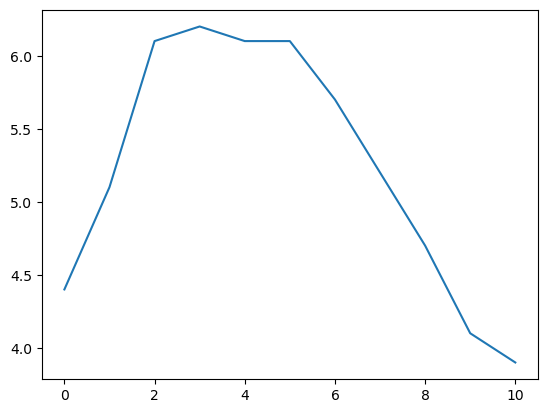

In [161]:
# Representación gráfica del objeto Series
%matplotlib inline
import matplotlib.pyplot as plt
series.plot()
plt.show()

## Creación de un objeto DataFrame

In [162]:
# Creación de un DataFrame inicializándolo con un diccionario de objetios Series
personas = {
    "peso": pd.Series([84, 90, 56, 64], ["Santiago","Pedro", "Ana", "Julia"]),
    "altura": pd.Series({"Santiago": 187, "Pedro": 178, "Julia": 170, "Ana": 165}),
    "hijos": pd.Series([2, 3], ["Pedro", "Julia"])
}

dataFrame = pd.DataFrame( personas )
dataFrame 

,peso,altura,hijos
Ana,56,165,NaN
Julia,64,170,3.0
Pedro,90,178,2.0
Santiago,84,187,NaN


Puede forzarse al DataFrame a que presente unas columnas determinadas y en un orden determinado

In [163]:
# Creación de un DataFrame inicializándolo con algunos elementos de un diccionario
# de objetos Series
personas = {
    "peso": pd.Series([84, 90, 56, 64], ["Santiago","Pedro", "Ana", "Julia"]),
    "altura": pd.Series({"Santiago": 187, "Pedro": 178, "Julia": 170, "Ana": 165}),
    "hijos": pd.Series([2, 3], ["Pedro", "Julia"])
}

dataFrame = pd.DataFrame( personas, columns=[ "peso", "altura" ], index=[ "Ana", "Julia", "Santiago" ] )
dataFrame 


,peso,altura
Ana,56,165
Julia,64,170
Santiago,84,187


In [164]:
# Creación de un DataFrame inicializándolo con una lista de listas de Python
# Importante: Deben especificarse las columnas e indices por separado
valores = [
    [185, 4, 76],
    [170, 0, 65],
    [190, 1, 89]
]

dataFrame = pd.DataFrame( valores, columns=[ "altura", "hijos", "peso" ], index=[ "Pedro", "Ana", "Juan" ] )
dataFrame 



,altura,hijos,peso
Pedro,185,4,76
Ana,170,0,65
Juan,190,1,89


In [165]:
# Creación de un DataFrame inicializándolo con un diccionario de Python
personas = {
    "altura": {"Santiago": 187, "Pedro": 178, "Julia": 170, "Ana": 165}, 
    "peso": {"Santiago": 87, "Pedro": 78, "Julia": 70, "Ana": 65}}


dataFrame = pd.DataFrame( personas )
dataFrame 

,altura,peso
Santiago,187,87
Pedro,178,78
Julia,170,70
Ana,165,65


## Acceso a los elementos de un DataFrame

In [166]:
# Creación de un DataFrame inicializándolo con un diccionario de objetios Series
personas = {
    "peso": pd.Series([84, 90, 56, 64], ["Santiago","Pedro", "Ana", "Julia"]),
    "altura": pd.Series({"Santiago": 187, "Pedro": 178, "Julia": 170, "Ana": 165}),
    "hijos": pd.Series([2, 3], ["Pedro", "Julia"])
}


dataFrame = pd.DataFrame( personas )
print( dataFrame )

          peso  altura  hijos
Ana         56     165    NaN
Julia       64     170    3.0
Pedro       90     178    2.0
Santiago    84     187    NaN


### Acceso a los elementos de las columnas del DataFrame

In [167]:
# acceder a los objetos series de la columna peso
dataFrame["peso"]

Ana         56
Julia       64
Pedro       90
Santiago    84
Name: peso, dtype: int64

In [168]:
# acceder a múltiples columnas (peso y altura)
dataFrame[ [ "peso", "altura" ] ]

,peso,altura
Ana,56,165
Julia,64,170
Pedro,90,178
Santiago,84,187


In [169]:
# Pueden combinarse los metodos anteriores con expresiones booleanas
# devolver los valores de la columna peso que sean mayores a 80
dataFrame[dataFrame[ "peso" ] > 80 ]

,peso,altura,hijos
Pedro,90,178,2.0
Santiago,84,187,NaN


In [170]:
# Pueden combinarse los metodos anteriores con expresiones booleanas
# obtener aquellos valores cuyo peso sea mayor a 80 y altura mayor a 180

dataFrame[ ( dataFrame[ "peso" ] > 80 ) & ( dataFrame[ "altura" ] > 180 )  ]

,peso,altura,hijos
Santiago,84,187,NaN


### Acceso a los elementos de las filas del DataFrame

In [171]:
# Mostrar el DataFrame
dataFrame

,peso,altura,hijos
Ana,56,165,NaN
Julia,64,170,3.0
Pedro,90,178,2.0
Santiago,84,187,NaN


In [172]:
# Acceder a la fila cuyo índice es Pedro
dataFrame.loc[ "Pedro" ]

peso       90.0
altura    178.0
hijos       2.0
Name: Pedro, dtype: float64

In [173]:
# Acceder a la fila cuyo índice es 2
dataFrame.iloc[ 2 ]

peso       90.0
altura    178.0
hijos       2.0
Name: Pedro, dtype: float64

In [174]:
# Hacer un slicing para obtener los datos de los ínidces ente 1 y 3
dataFrame.iloc[ 1 : 3 ]

,peso,altura,hijos
Julia,64,170,3.0
Pedro,90,178,2.0


### Consulta avanzada de los elementos de un DataFrame

In [175]:
# Mostrar el DataFrame
dataFrame

,peso,altura,hijos
Ana,56,165,NaN
Julia,64,170,3.0
Pedro,90,178,2.0
Santiago,84,187,NaN


In [176]:
# Realizar filtros en forma de texto (registros cuya altura sea mayor o igual a 170
# y peso mayor a 60)
dataFrame.query( " altura >= 170 and peso > 60 " )

,peso,altura,hijos
Julia,64,170,3.0
Pedro,90,178,2.0
Santiago,84,187,NaN


## Copiar un DataFrame

In [177]:
# Creación de un DataFrame inicializándolo con un diccionario de objetios Series
personas = {
    "peso": pd.Series([84, 90, 56, 64], ["Santiago","Pedro", "Ana", "Julia"]),
    "altura": pd.Series({"Santiago": 187, "Pedro": 178, "Julia": 170, "Ana": 165}),
    "hijos": pd.Series([2, 3], ["Pedro", "Julia"])
}

dataFrame = pd.DataFrame( personas )
print( dataFrame )


          peso  altura  hijos
Ana         56     165    NaN
Julia       64     170    3.0
Pedro       90     178    2.0
Santiago    84     187    NaN


In [178]:
# Copia del DataFrame df en df_copy
# Importante: Al modificar un elemento de df_copy no se modifica df
dataFrameCopy = dataFrame.copy()
dataFrameCopy

,peso,altura,hijos
Ana,56,165,NaN
Julia,64,170,3.0
Pedro,90,178,2.0
Santiago,84,187,NaN


## Modificación de un DataFrame

In [179]:
# Creación de un DataFrame inicializándolo con un diccionario de objetios Series
personas = {
    "peso": pd.Series([84, 90, 56, 64], ["Santiago","Pedro", "Ana", "Julia"]),
    "altura": pd.Series({"Santiago": 187, "Pedro": 178, "Julia": 170, "Ana": 165}),
    "hijos": pd.Series([2, 3], ["Pedro", "Julia"])
}

dataFrame = pd.DataFrame( personas )
dataFrame


,peso,altura,hijos
Ana,56,165,NaN
Julia,64,170,3.0
Pedro,90,178,2.0
Santiago,84,187,NaN


In [180]:
# Añadir una nueva columna al DataFrame
dataFrame["cumpleanos"] = [ 1980, 1987, 1980, 1994 ]
dataFrame

,peso,altura,hijos,cumpleanos
Ana,56,165,NaN,1980
Julia,64,170,3.0,1987
Pedro,90,178,2.0,1980
Santiago,84,187,NaN,1994


In [181]:
# Añadir una nueva columna calculada al DataFrame
dataFrame[ "edad" ] = 2026 - dataFrame["cumpleanos"] 
dataFrame

,peso,altura,hijos,cumpleanos,edad
Ana,56,165,NaN,1980,46
Julia,64,170,3.0,1987,39
Pedro,90,178,2.0,1980,46
Santiago,84,187,NaN,1994,32


In [182]:
# Añadir una nueva columna creando un DataFrame nuevo
dataFrameMod = dataFrame.assign( mascotas = [ 1, 3, 0, 0 ] )
dataFrameMod

,peso,altura,hijos,cumpleanos,edad,mascotas
Ana,56,165,NaN,1980,46,1
Julia,64,170,3.0,1987,39,3
Pedro,90,178,2.0,1980,46,0
Santiago,84,187,NaN,1994,32,0


In [183]:
# si mostramos el dataframe original se aprecia que no se ha modificado
dataFrame

,peso,altura,hijos,cumpleanos,edad
Ana,56,165,NaN,1980,46
Julia,64,170,3.0,1987,39
Pedro,90,178,2.0,1980,46
Santiago,84,187,NaN,1994,32


In [184]:
# Eliminar una columna existente del DataFrame
del( dataFrame["peso"] )
dataFrame

,altura,hijos,cumpleanos,edad
Ana,165,NaN,1980,46
Julia,170,3.0,1987,39
Pedro,178,2.0,1980,46
Santiago,187,NaN,1994,32


In [185]:
# Eliminar una columna existente devolviendo una copia del DataFrame resultante
dataFrameMod = dataFrame.drop(["hijos"], axis=1)
dataFrameMod

,altura,cumpleanos,edad
Ana,165,1980,46
Julia,170,1987,39
Pedro,178,1980,46
Santiago,187,1994,32


In [186]:
dataFrame

,altura,hijos,cumpleanos,edad
Ana,165,NaN,1980,46
Julia,170,3.0,1987,39
Pedro,178,2.0,1980,46
Santiago,187,NaN,1994,32


## Evaluación de expresiones sobre un DataFrame

In [187]:
# Creación de un DataFrame inicializándolo con un diccionario de objetios Series
personas = {
    "peso": pd.Series([84, 90, 56, 64], ["Santiago","Pedro", "Ana", "Julia"]),
    "altura": pd.Series({"Santiago": 187, "Pedro": 178, "Julia": 170, "Ana": 165}),
    "hijos": pd.Series([2, 3], ["Pedro", "Julia"])
}


dataFrame = pd.DataFrame( personas )
dataFrame

,peso,altura,hijos
Ana,56,165,NaN
Julia,64,170,3.0
Pedro,90,178,2.0
Santiago,84,187,NaN


In [188]:
# Evaluar una función sobre una columna del DataFrame
dataFrame.eval( "altura/2" )

Ana         82.5
Julia       85.0
Pedro       89.0
Santiago    93.5
Name: altura, dtype: float64

In [189]:
# Asignar el valor resultante como una nueva columna
dataFrame.eval( "mediaAltura = altura/2", inplace=True)
dataFrame

,peso,altura,hijos,mediaAltura
Ana,56,165,NaN,82.5
Julia,64,170,3.0,85.0
Pedro,90,178,2.0,89.0
Santiago,84,187,NaN,93.5


In [190]:
# Evaluar una función utilizando una variable local
maxAltura = 180

dataFrame.eval( "altura > @maxAltura" )


Ana         False
Julia       False
Pedro       False
Santiago     True
Name: altura, dtype: bool

In [191]:
# Aplicar una función externa a una columna del DataFrame
def func(x):
    return x + 2

dataFrame["peso"].apply(func)


Ana         58
Julia       66
Pedro       92
Santiago    86
Name: peso, dtype: int64

In [192]:
dataFrame

,peso,altura,hijos,mediaAltura
Ana,56,165,NaN,82.5
Julia,64,170,3.0,85.0
Pedro,90,178,2.0,89.0
Santiago,84,187,NaN,93.5


## Guardar y Cargar el DataFrame

In [193]:
# Creación de un DataFrame inicializándolo con un diccionario de objetios Series
personas = {
    "peso": pd.Series([84, 90, 56, 64], ["Santiago","Pedro", "Ana", "Julia"]),
    "altura": pd.Series({"Santiago": 187, "Pedro": 178, "Julia": 170, "Ana": 165}),
    "hijos": pd.Series([2, 3], ["Pedro", "Julia"])
}

dataFrame = pd.DataFrame( personas )
dataFrame

,peso,altura,hijos
Ana,56,165,NaN
Julia,64,170,3.0
Pedro,90,178,2.0
Santiago,84,187,NaN


In [194]:
# Guardar el DataFrame como CSV, HTML y JSON
dataFrame.to_csv("dataFRame.csv")
dataFrame.to_html("dataFRame.html")
dataFrame.to_json("dataFRame.json")

In [195]:
# Cargar el DataFrame en Jupyter
dataFramecsv = pd.read_csv("dataFRame.csv")
dataFramecsv

,Unnamed: 0,peso,altura,hijos
0,Ana,56,165,NaN
1,Julia,64,170,3.0
2,Pedro,90,178,2.0
3,Santiago,84,187,NaN


In [196]:
# Cargar el DataFrame con la primera columna correctamente asignada
dataFramecsv = pd.read_csv("dataFRame.csv", index_col=0)
dataFramecsv

,peso,altura,hijos
Ana,56,165,NaN
Julia,64,170,3.0
Pedro,90,178,2.0
Santiago,84,187,NaN
